# 선형 회귀
선형 회귀는 단순하게 입력값 `x(n, m)`을 통해 정답`y(n, )`을 통해 `y = Wx + b` 형태로 수식을 만들게 학습시키는 방식의 머신러닝입니다.

## 진행 방식
이제 본격적으로 처음부터 시작하는 것이기 때문에 클래식하고 깔끔한 순서로 가겠습니다.
1. 어떤 문제 해결(예측)할지 정의하기
2. 데이터 준비하기
3. 전처리 하기
4. 모델 학습시키기
5. 평가 지표 확인하기
6. 조정하기
7. 시각화 하기

# 문제 정의와 데이터 준비
## 데이터셋
지도 학습을 통한 선형 회귀를 하기 위해선 적절한 문제와 데이터가 필요하기 때문에 적당한 데이터셋인 `UCI Auto MPG` 데이터셋을 선택하겠습니다. 이것은 미국 캘리포니아 대학교 어바인(UCI) 머신러닝 저장소에서 제공되는 대표적인 자동차 연비 데이터셋이라고 합니다.

## 문제 정의
이에 따라 자연스럽게 자동차의 무게, 마력, 배기량 등을 통해 연비(mpg)를 예측하려 합니다. 

> 연비 mpg: 자동차가 연료 1갤런으로 몇 마일을 갈 수 있는지

In [1]:
# 필요한 데이터 가져오기
# pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd

# 데이터셋 받아오기
auto_mpg = fetch_ucirepo(id=9)

print(type(auto_mpg))

<class 'ucimlrepo.dotdict.dotdict'>


In [2]:
print(auto_mpg.keys())

dict_keys(['data', 'metadata', 'variables'])


In [3]:
print(auto_mpg.metadata)

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [4]:
auto_mpg.data.features
# displacement: 엔진 실린더들이 밀어내는 전체 부피. 보통 엔진 배기량이 클수록 연비가 낮아짐
# cylinders: 기통 - 일반적으로 실린더가 많을수록 폭발이 촘촘하게 일어나 승차감이 부드럽고 연비가 낮아진다 함
# horsepower: 마력 - 많은 연료를 통해 강한 힘을 내는 량 (엔진의 최대 성능)
# weight: 자동차 무게 (lbs)
# acceleration: 0~60mph까지 가는 데 걸리는 시간 (초)
# model_year: 연식
# origin: 제조 지역 코드.
#      보통 1: USA 2: Europe 3. Japan 으로 쓰임

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [5]:
X = auto_mpg.data.features
y = auto_mpg.data.targets["mpg"]

In [6]:
df = pd.concat([X, y], axis = 1)
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [7]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [8]:
# 결측치 horsepower에 6개 있음
print(df.isna().sum())

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


In [9]:
df = df.dropna(axis=0)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(scaler.fit_transform(df), columns=df.columns).corr().rename(columns={
  "displacement": "배기량", 
  "cylinders": "실린더", 
  "horsepower": "마력", 
  "weight": "무게", 
  "acceleration": "가속시간", 
  "model_year": "연식", 
  "origin": "출처", 
  "mpg": "연비"
}).loc[['mpg']]
# 배기량: -0.8
# 실린더: -0.77
# 마력: -0.77
# 무게: -0.83
# 가속 시간: 0.42
# 연식: 0.57
# # # # # # # # # # # [해석] # # # # # # # #
# 여기에서 연비는 높을수록 좋기 때문에 배기량, 실린더 수, 마력, 무게가 역관계를 가지며 
# 연식이 높을수록 연비가 좋아집니다.


,배기량,실린더,마력,무게,가속시간,연식,출처,연비
mpg,-0.805127,-0.777618,-0.778427,-0.832244,0.423329,0.580541,0.565209,1.0


In [11]:
# 데이터 예측 해보기
from sklearn.model_selection import train_test_split

# 데이터 분리하기
X = df[["weight"]]
y = df["mpg"]

X_train, X_test, y_train, y_test =  train_test_split(
  X, y,
  test_size=0.2,
  random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 편차 절대 평균
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

coef = float(model.coef_[0])
intercept = float(model.intercept_)
print("기울기 w:", coef) # 계수
print("편향 b:", intercept) # 절편
print("MAE (평균 절대 오차):", mae)
print("RMSE (평균 제곱근 오차):", rmse)
print("R2 (결정계수):", r2) # 무게로 연비를 얼마나 설명 가능한지

기울기 w: -0.007903610385225605
편향 b: 47.200526427552106
MAE (평균 절대 오차): 3.4641211922147592
RMSE (평균 제곱근 오차): 4.206350944648542
R2 (결정계수): 0.6533466675646016


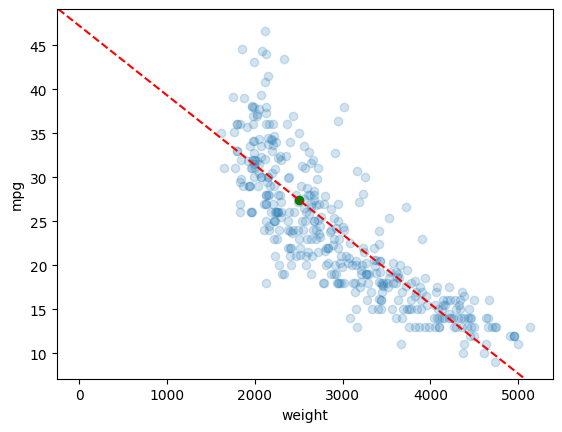

In [13]:
import matplotlib.pyplot as plt

plt.scatter(X["weight"], y, alpha=0.2)

plt.xlabel('weight')
plt.ylabel('mpg')

plt.axline((0, intercept), slope=coef, color='red', linestyle='--')

# 만들어진 선으로 하나 예측해보기
ex_weight = 2500
ex_mpg_pred = ex_weight * coef + intercept

plt.scatter([ex_weight], [ex_mpg_pred], color="green")



plt.show()

# 결과 후 생각
솔직히 이거 하나로는 큰 의미가 있나? 라는 생각이 듭니다.

무게가 `mpg`에 대해서 약 `-0.008` 정도의 영향을 미친다는것 정도는 알겠습니다. (범위가 다르기 때문에)

따라서 이번에는 표준화를 먼저 해보겠습니다.

In [14]:
# 표준화하기
df.columns

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'mpg'],
      dtype='str')

In [18]:
scaler = StandardScaler().fit_transform(df)
stand_df = pd.DataFrame(scaler, columns=df.columns)
stand_df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02
mean,-7.250436e-17,-1.087565e-16,-1.812609e-16,-1.812609e-17,4.350262e-16,-1.160070e-15,1.359457e-16,1.450087e-16
std,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00
min,-1.209563e+00,-1.451004e+00,-1.520975e+00,-1.608575e+00,-2.736983e+00,-1.625315e+00,-7.166410e-01,-1.853218e+00
25%,-8.555316e-01,-8.640136e-01,-7.665929e-01,-8.868535e-01,-6.410551e-01,-8.098841e-01,-7.166410e-01,-8.269250e-01
50%,-4.153842e-01,-8.640136e-01,-2.853488e-01,-2.052109e-01,-1.499869e-02,5.547151e-03,-7.166410e-01,-8.927701e-02
75%,7.782764e-01,1.483947e+00,5.600800e-01,7.510927e-01,5.384714e-01,8.209784e-01,5.263824e-01,7.125143e-01
max,2.493416e+00,1.483947e+00,3.265452e+00,2.549061e+00,3.360262e+00,1.636410e+00,1.769406e+00,2.970359e+00


In [71]:
# 같은 과정 반복
X = stand_df.iloc[:, :-1]
y = stand_df["mpg"]

print(X.columns)
print(y.shape)

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin'],
      dtype='str')
(392,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42
)

model.fit(X_train, y_train)

model.score(X_test, y_test)

0.7901500386760343

In [77]:
# 수식의 편향과 계수 알아보기
print("bias:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
  print(f"{feature}: {coef:.4f}")

print("R2:", r2_score(y_test, model.predict(X_test)))

bias: 0.006868311998279166
displacement: 0.2026
cylinders: -0.0756
horsepower: -0.1051
weight: -0.6684
acceleration: 0.0134
model_year: 0.3624
origin: 0.1665
R2: 0.7901500386760343


In [76]:
# 직접 벡터 만들어서 행렬곱 수식으로 만들어보기
vector = pd.Series([e for e in model.coef_])

print("# # [계수] # #")
print(np.array(vector).reshape(7, 1))
print("# # [편향] # #")
print(model.intercept_)

print("\n --- 직접 예측 --- \n")
# print(vector.shape)
# print(np.array(X.iloc[[0, 2]]))

answer = y[[0, 2]]
# print(np.ndarray(df.iloc[0]))
# print(np.ndarray(vector))
print(pd.concat((
  X.iloc[[0, 2]],
  pd.concat((
    pd.DataFrame(X.iloc[[0, 2]] @ np.array(vector).reshape(7, 1) + model.intercept_).rename(columns={0: "예측"}), 
    answer.loc[[0, 2]].rename('실제 mpg')), axis=1)
), axis=1))

# # [계수] # #
[[ 0.20256687]
 [-0.0755721 ]
 [-0.10505166]
 [-0.66838015]
 [ 0.01341433]
 [ 0.36235217]
 [ 0.16651733]]
# # [편향] # #
0.006868311998279166

 --- 직접 예측 --- 

   displacement  cylinders  horsepower    weight  acceleration  model_year  \
0      1.077290   1.483947    0.664133  0.620540     -1.285258   -1.625315   
2      1.182542   1.483947    1.184397  0.540382     -1.648189   -1.625315   

     origin        예측    실제 mpg  
0 -0.716641 -1.097089 -0.698638  
2 -0.716641 -1.081715 -0.698638  


# 결론
처음에 나왔던 상관계수와 모델링 후 회귀계수를 비교하면

|  | 배기량 | 실린더 | 마력 | 무게 | 가속시간 | 연식 | 출처 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 상관계수 | -0.8051 | -0.7776 | -0.7784 | -0.8322 |	0.4233 | 0.5805 | 0.5652 |
| 회귀계수 | 0.2025 | -0.07557 | -0.1050 | -0.6683 |	 0.0134 | 0.3623 | 0.1665 |

과 같은 결과가 나온다.



여기에서 일단 출처는 원핫 인코딩이 안 되어 있으니 넘어가고, 배기량이 강한 반대의 상관성을 띠었었는데 회귀로 돌아가니 약한 양의 상관관계를 가지고, 실린더와 마력, 가속시간은 약한 상관성으로 바뀌었다. 비슷한 영향을 유지하는 것은 연식과 무게 정도뿐이었다.

왜 이럴까? 

실제로 상관계수는 두 변수의 선형 관계이기 때문에 1:1로 강한 상관성을 보여줄 수 있지만 실제 회귀식을 만들 때에는 비슷한 속성을 설명하는 것들이 있기 때문에 이것들이 작아지는 것이 자연스럽습니다.

이해하기 쉽게 예시를 나타내어 보면 `낮은 무게`, `적은 실린더`, `낮은 마력`은 모두 `작은 차`의 속성을 나타낼 확률이 높습니다.

따라서 예를 들어 다중 회귀의 계수는 변수 하나가 아니라 **다른 변수가 동일할 때 자기만 변할 때의 변화량**을 나타내기 때문에 자연스럽게 계수가 낮아지게 됩니다.

### 배기량을 보면
특히 배기량 같은 경우에는 처음에는 강한 음의 상관계수를 띄었지만 회귀 계수에는 약한 양의 계수를 보였습니다.

이는 배기량이 높은 경우에는 대체로 무겁거나 실린더가 많기 때문입니다. 실제로 현재 모델에서 배기량만 높아진다면 예측되는 연비는 좋아지겠지만 그런 경우는 데이터상 많이 없고 배기량이 높아짐에 따라 배기량과 얽혀 있는 요소의 영향으로 인해 연비가 안 좋아지는 경우가 많다고 해석할 수 있습니다.